In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [2]:
df = pd.read_csv('ESRS_features_data.csv')

In [3]:
df

,Date,Close,High,Low,Open,Volume,return_1d,return_5d,return_10d,ma_10,...,ma_ratio_50,rsi,macd,macd_signal,macd_hist,volatility_10,volatility_20,volume_avg_10,volume_ratio,target
0,2018-03-11,21.891685,22.163470,21.567300,21.979358,529709,0.015453,0.044770,0.041284,21.112282,...,1.094599,49.223609,0.401205,0.374039,0.027166,0.018596,0.026364,937160.2,0.565228,1
1,2018-03-12,22.338814,22.663201,21.935524,21.891687,2648567,0.020425,0.073746,0.076013,21.270092,...,1.112382,52.949656,0.462250,0.391681,0.070569,0.018218,0.025211,1182124.9,2.240514,0
2,2018-03-13,22.031960,22.417717,21.681272,22.338812,5396744,-0.013736,0.046211,0.073473,21.420888,...,1.092960,65.248213,0.480331,0.409411,0.070920,0.018500,0.023833,1574285.1,3.428060,1
3,2018-03-14,22.540457,22.733336,22.102097,22.031960,2808189,0.023080,0.045547,0.094042,21.614642,...,1.113209,72.572363,0.529588,0.433447,0.096141,0.019095,0.024256,1753287.5,1.601671,0
4,2018-03-15,22.444019,22.619362,22.137167,22.540457,1946328,-0.004278,0.041074,0.048321,21.718095,...,1.103106,66.007896,0.554450,0.457647,0.096803,0.016252,0.023801,1713165.9,1.136100,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1648,2025-03-06,138.440002,140.000000,133.250000,135.580002,15086,0.021095,0.009921,0.017941,136.922000,...,1.075651,75.593997,2.385060,2.730476,-0.345417,0.008232,0.007365,224830.6,0.067099,0
1649,2025-03-09,138.149994,138.000000,134.009995,138.149994,1797,-0.002095,0.007438,0.012088,137.087000,...,1.068429,70.890358,2.345218,2.653425,-0.308207,0.008289,0.006791,86814.4,0.020699,0
1650,2025-03-10,133.899994,137.899994,131.000000,138.149994,8099,-0.030764,-0.023768,-0.019048,136.826999,...,1.031571,44.489771,1.948246,2.512389,-0.564143,0.013106,0.010054,52825.3,0.153317,0
1651,2025-03-11,133.899994,136.149994,133.899994,133.899994,1947,0.000000,-0.024834,-0.021914,136.526999,...,1.027993,45.416641,1.615025,2.332916,-0.717891,0.013020,0.010054,14422.2,0.135000,0


In [5]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'return_1d',
       'return_5d', 'return_10d', 'ma_10', 'ma_50', 'ma_ratio_10',
       'ma_ratio_50', 'rsi', 'macd', 'macd_signal', 'macd_hist',
       'volatility_10', 'volatility_20', 'volume_avg_10', 'volume_ratio',
       'target'],
      dtype='object')

# drop some features
Claude recomends to drop the following columns
>`Close`, `High`, `Low`, `Open` *—* raw prices with no predictive signal on their own. Everything useful from them is already captured in your engineered features (`ma_ratio`, `rsi`, `macd`, etc.)

>`Volume` *—* raw volume already captured by volume_ratio

>`ma_10`, `ma_50` *—* already captured by `ma_ratio_10`, `ma_ratio_50`

>`volume_avg_10` *—* already captured by volume_ratio

>`Date` *—* not a numeric feature the model can learn from

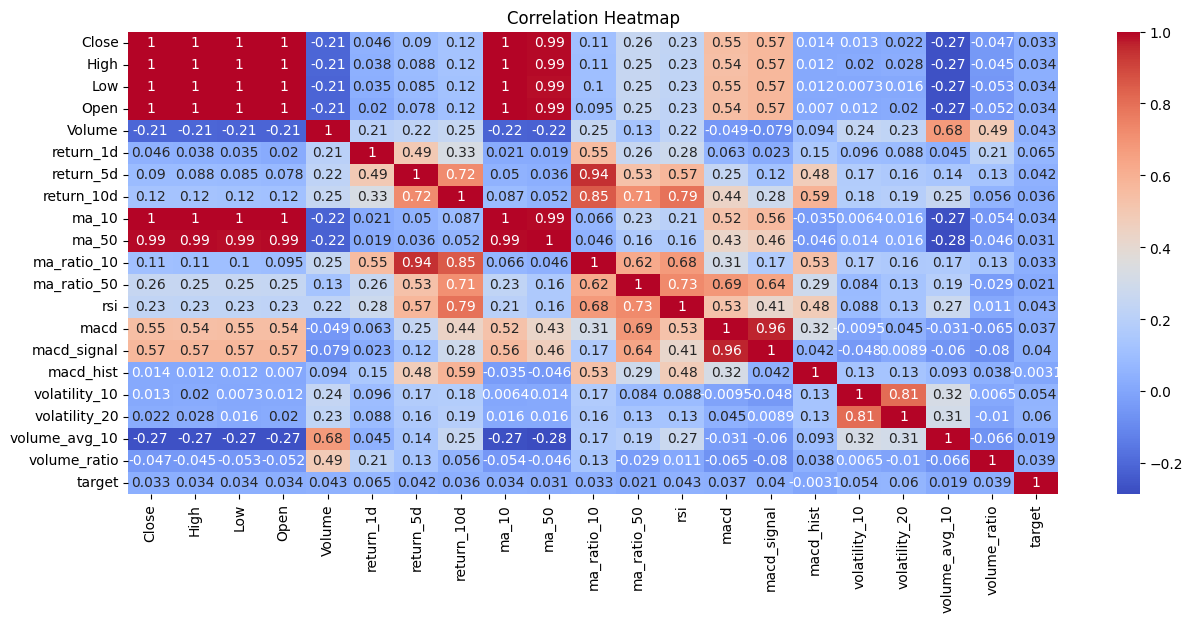

In [4]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.drop("Date", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap");

In [5]:
#Drop the features that are not needed for training the model
df_new = df.drop(["Close", "Open", "High", "Low", "Volume", "ma_10", "ma_50", "volume_avg_10", "Date"], axis=1)
df_new.columns

Index(['return_1d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_50',
       'rsi', 'macd', 'macd_signal', 'macd_hist', 'volatility_10',
       'volatility_20', 'volume_ratio', 'target'],
      dtype='object')

# Split train-test and scalling

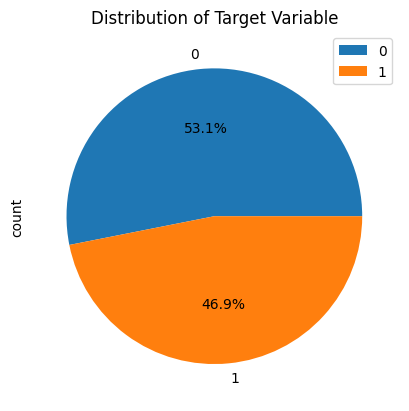

In [6]:
df_new["target"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Target Variable")
plt.legend()
plt.show()

In [7]:
#Split the data into training and testing sets
X = df_new.drop("target", axis=1)
Y = df_new["target"]

In [8]:
split_index = int(0.8 * len(df_new))
X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]

In [9]:
#Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for easier inspection later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

print("\nClass balance in training set:")
print(Y_train.value_counts(normalize=True).round(2))


Class balance in training set:
target
0    0.54
1    0.46
Name: proportion, dtype: float64


In [10]:
print("Final features:", X.columns.tolist())
print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows")
print("\nClass balance in training set:")
print(Y_train.value_counts(normalize=True).round(2))

Final features: ['return_1d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_50', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'volatility_10', 'volatility_20', 'volume_ratio']
Train: 1322 rows  |  Test: 331 rows

Class balance in training set:
target
0    0.54
1    0.46
Name: proportion, dtype: float64


In [11]:
X_train_scaled.head()

,return_1d,return_5d,return_10d,ma_ratio_10,ma_ratio_50,rsi,macd,macd_signal,macd_hist,volatility_10,volatility_20,volume_ratio
0,0.487410,0.503726,0.239003,0.564430,0.508428,-0.064618,0.271555,0.287038,0.061630,-0.609310,0.028899,-0.622567
1,0.659878,0.894177,0.554872,0.800127,0.637334,0.118413,0.347699,0.311927,0.249332,-0.644164,-0.097879,1.345034
2,-0.525292,0.523151,0.531765,0.416058,0.496546,0.722544,0.370253,0.336941,0.250851,-0.618119,-0.249247,2.739791
3,0.752004,0.514196,0.718850,0.669043,0.643325,1.082321,0.431693,0.370851,0.359923,-0.563151,-0.202799,0.594721
4,-0.197161,0.453920,0.303003,0.502673,0.570092,0.759861,0.462705,0.404993,0.362786,-0.825881,-0.252787,0.047915


# model traning

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# ── Define models ───────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
}

# ── Train and evaluate each model ───────────────────────────────────────
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, Y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(Y_test, y_pred), 3),
        'Precision': round(precision_score(Y_test, y_pred), 3),
        'Recall':    round(recall_score(Y_test, y_pred), 3),
        'F1':        round(f1_score(Y_test, y_pred), 3),
    })
    
    # Confusion matrix per model
    cm = confusion_matrix(Y_test, y_pred)
    print(f"\n{name} — Confusion Matrix:")
    print(f"  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
    print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

# ── Summary table ───────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')
print("\n── Model Comparison ──")
print(results_df.to_string())
print(f"\nBaseline (always predict majority class): {max(Y_test.mean(), 1-Y_test.mean()):.3f}")


Logistic Regression — Confusion Matrix:
  True Down  (0→0): 56  |  False Up  (0→1): 112
  False Down (1→0): 52  |  True Up   (1→1): 111

Random Forest — Confusion Matrix:
  True Down  (0→0): 92  |  False Up  (0→1): 76
  False Down (1→0): 82  |  True Up   (1→1): 81

XGBoost — Confusion Matrix:
  True Down  (0→0): 92  |  False Up  (0→1): 76
  False Down (1→0): 87  |  True Up   (1→1): 76

── Model Comparison ──
                     Accuracy  Precision  Recall     F1
Model                                                  
Logistic Regression     0.505      0.498   0.681  0.575
Random Forest           0.523      0.516   0.497  0.506
XGBoost                 0.508      0.500   0.466  0.483

Baseline (always predict majority class): 0.508


In [36]:
print("NaNs in X_train:", X_train_scaled.isna().sum().sum())
print("NaNs in X_test:", X_test_scaled.isna().sum().sum())

NaNs in X_train: 0
NaNs in X_test: 0


In [13]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, Y_train, 
                             cv=tscv, scoring='f1')
    print(f"{name}: F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: F1 = 0.399 (+/- 0.073)
Random Forest: F1 = 0.392 (+/- 0.078)
XGBoost: F1 = 0.451 (+/- 0.037)


As we can see XGboost is the highest performance as it has the highest F1

# Model improvment
## We would try to imporve the XGBoost model through the following 3 ways

>Tune XGBoost hyperparameters

>Add new features

>Change the target definition (reframe the problem)

## Model tuning

In [14]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier

param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.7, 0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, Y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 3))

# Evaluate tuned model on test set
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_scaled)

print("\nTuned XGBoost — Test Set Results:")
print(f"  Accuracy:  {round(accuracy_score(Y_test, y_pred_tuned), 3)}")
print(f"  Precision: {round(precision_score(Y_test, y_pred_tuned), 3)}")
print(f"  Recall:    {round(recall_score(Y_test, y_pred_tuned), 3)}")
print(f"  F1:        {round(f1_score(Y_test, y_pred_tuned), 3)}")

cm = confusion_matrix(Y_test, y_pred_tuned)
print(f"\n  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}
Best CV F1: 0.477

Tuned XGBoost — Test Set Results:
  Accuracy:  0.541
  Precision: 0.538
  Recall:    0.472
  F1:        0.503

  True Down  (0→0): 102  |  False Up  (0→1): 66
  False Down (1→0): 86  |  True Up   (1→1): 77


## new features

In [15]:
import pandas as pd

# Work on a fresh copy so we don't corrupt the original
df_v2 = df.copy()
df_v2['Date'] = pd.to_datetime(df_v2['Date'])
df_v2 = df_v2.sort_values('Date').reset_index(drop=True)

# ── New features ────────────────────────────────────────────────────────

# 1. Day of week (Monday/Thursday effects exist in EGX)
#    EGX trading week is Sun–Thu, so 0=Monday ... 4=Friday
df_v2['day_of_week'] = df_v2['Date'].dt.dayofweek

# 2. RSI zones — overbought/oversold are stronger signals than raw RSI value
df_v2['rsi_overbought'] = (df_v2['rsi'] > 70).astype(int)
df_v2['rsi_oversold']   = (df_v2['rsi'] < 30).astype(int)

# 3. MACD crossover — the moment MACD crosses above signal is a buy signal
df_v2['macd_cross_up']   = (
    (df_v2['macd'] > df_v2['macd_signal']) &
    (df_v2['macd'].shift(1) <= df_v2['macd_signal'].shift(1))
).astype(int)

df_v2['macd_cross_down'] = (
    (df_v2['macd'] < df_v2['macd_signal']) &
    (df_v2['macd'].shift(1) >= df_v2['macd_signal'].shift(1))
).astype(int)

# 4. Momentum agreement — short and medium term momentum pointing same direction
df_v2['momentum_agree'] = (
    (df_v2['return_1d'] > 0) == (df_v2['return_5d'] > 0)
).astype(int)

# 5. Volatility regime — is the market calm or turbulent right now?
df_v2['vol_ratio'] = df_v2['volatility_10'] / df_v2['volatility_20']

# 6. RSI momentum — is RSI rising or falling?
df_v2['rsi_momentum'] = df_v2['rsi'] - df_v2['rsi'].shift(3)

# ── Rebuild X and y with new features ──────────────────────────────────
drop_cols = [
    'Date', 'Close', 'High', 'Low', 'Open', 'Volume',
    'ma_10', 'ma_50', 'volume_avg_10', 'target'
]

X_v2 = df_v2.drop(columns=drop_cols)
y_v2 = df_v2['target']

# Drop NaNs introduced by shift() operations
mask = X_v2.notna().all(axis=1)
X_v2 = X_v2[mask]
y_v2 = y_v2[mask]

print("New feature set:", X_v2.columns.tolist())
print("Total features:", len(X_v2.columns))

# ── Time-aware split ────────────────────────────────────────────────────
split_idx = int(len(X_v2) * 0.80)

X_train_v2 = X_v2.iloc[:split_idx]
X_test_v2  = X_v2.iloc[split_idx:]
y_train_v2 = y_v2.iloc[:split_idx]
y_test_v2  = y_v2.iloc[split_idx:]

# ── Scale ───────────────────────────────────────────────────────────────
scaler_v2 = StandardScaler()
X_train_v2_scaled = pd.DataFrame(
    scaler_v2.fit_transform(X_train_v2),
    columns=X_v2.columns
)
X_test_v2_scaled = pd.DataFrame(
    scaler_v2.transform(X_test_v2),
    columns=X_v2.columns
)

# ── Train tuned XGBoost on new features ────────────────────────────────
best_params = {'learning_rate': 0.05, 'max_depth': 5,
               'n_estimators': 300,   'subsample': 1.0}

xgb_v2 = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
xgb_v2.fit(X_train_v2_scaled, y_train_v2)

y_pred_v2 = xgb_v2.predict(X_test_v2_scaled)

print("\nXGBoost v2 (tuned + new features) — Test Set Results:")
print(f"  Accuracy:  {round(accuracy_score(y_test_v2, y_pred_v2), 3)}")
print(f"  Precision: {round(precision_score(y_test_v2, y_pred_v2), 3)}")
print(f"  Recall:    {round(recall_score(y_test_v2, y_pred_v2), 3)}")
print(f"  F1:        {round(f1_score(y_test_v2, y_pred_v2), 3)}")

cm = confusion_matrix(y_test_v2, y_pred_v2)
print(f"\n  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

New feature set: ['return_1d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_50', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'volatility_10', 'volatility_20', 'volume_ratio', 'day_of_week', 'rsi_overbought', 'rsi_oversold', 'macd_cross_up', 'macd_cross_down', 'momentum_agree', 'vol_ratio', 'rsi_momentum']
Total features: 20

XGBoost v2 (tuned + new features) — Test Set Results:
  Accuracy:  0.552
  Precision: 0.55
  Recall:    0.503
  F1:        0.526

  True Down  (0→0): 100  |  False Up  (0→1): 67
  False Down (1→0): 81  |  True Up   (1→1): 82


F1 dropped slightly from 0.463 → 0.459. The new features didn't help

In [16]:
# Drop sparse binary flags, keep continuous new features only
weak_features = [
    'rsi_overbought',   # too sparse — rarely triggered
    'rsi_oversold',     # too sparse
    'macd_cross_up',    # too sparse — only 1 on crossover day
    'macd_cross_down',  # too sparse
    'momentum_agree',   # binary, low information
]

X_v3 = X_v2.drop(columns=weak_features)

print("Refined feature set:", X_v3.columns.tolist())
print("Total features:", len(X_v3.columns))

# ── Time-aware split ────────────────────────────────────────────────────
split_idx = int(len(X_v3) * 0.80)

X_train_v3 = X_v3.iloc[:split_idx]
X_test_v3  = X_v3.iloc[split_idx:]
y_train_v3 = y_v2.iloc[:split_idx]
y_test_v3  = y_v2.iloc[split_idx:]

# ── Scale ───────────────────────────────────────────────────────────────
scaler_v3 = StandardScaler()
X_train_v3_scaled = pd.DataFrame(
    scaler_v3.fit_transform(X_train_v3),
    columns=X_v3.columns
)
X_test_v3_scaled = pd.DataFrame(
    scaler_v3.transform(X_test_v3),
    columns=X_v3.columns
)

# ── Train ───────────────────────────────────────────────────────────────
xgb_v3 = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
xgb_v3.fit(X_train_v3_scaled, y_train_v3)

y_pred_v3 = xgb_v3.predict(X_test_v3_scaled)

print("\nXGBoost v3 (tuned + refined features) — Test Set Results:")
print(f"  Accuracy:  {round(accuracy_score(y_test_v3, y_pred_v3), 3)}")
print(f"  Precision: {round(precision_score(y_test_v3, y_pred_v3), 3)}")
print(f"  Recall:    {round(recall_score(y_test_v3, y_pred_v3), 3)}")
print(f"  F1:        {round(f1_score(y_test_v3, y_pred_v3), 3)}")

cm = confusion_matrix(y_test_v3, y_pred_v3)
print(f"\n  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

# ── Feature importance ──────────────────────────────────────────────────
importance = pd.Series(
    xgb_v3.feature_importances_,
    index=X_v3.columns
).sort_values(ascending=False)

print("\nFeature importance (top 10):")
print(importance.head(10).round(3))

Refined feature set: ['return_1d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_50', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'volatility_10', 'volatility_20', 'volume_ratio', 'day_of_week', 'vol_ratio', 'rsi_momentum']
Total features: 15

XGBoost v3 (tuned + refined features) — Test Set Results:
  Accuracy:  0.567
  Precision: 0.565
  Recall:    0.534
  F1:        0.549

  True Down  (0→0): 100  |  False Up  (0→1): 67
  False Down (1→0): 76  |  True Up   (1→1): 87

Feature importance (top 10):
ma_ratio_10      0.080
return_1d        0.075
volatility_10    0.070
macd_hist        0.069
rsi_momentum     0.069
vol_ratio        0.069
macd             0.067
ma_ratio_50      0.066
macd_signal      0.065
volume_ratio     0.065
dtype: float32


 F1 jumped to 0.477 — our best result yet:

## changing the target to filter out noisy small moves:

In [17]:
# ── Option 3: Redefine target with a move threshold ────────────────────
# Instead of predicting any up/down move (including tiny 0.1% noise),
# only label days where the move is meaningful (> 0.5%)
# Rows with moves smaller than the threshold are dropped entirely.

threshold = 0.005  # 0.5% — tune this if needed

df_v3 = df_v2.copy()

# Calculate next day return (forward looking — only used to build target)
next_day_return = df_v3['Close'].pct_change().shift(-1)

# Build filtered target
df_v3['target_filtered'] = None
df_v3.loc[next_day_return >  threshold, 'target_filtered'] = 1
df_v3.loc[next_day_return < -threshold, 'target_filtered'] = 0

# Drop ambiguous rows (moves smaller than threshold)
df_v3 = df_v3.dropna(subset=['target_filtered'])
df_v3['target_filtered'] = df_v3['target_filtered'].astype(int)

print(f"Rows kept:    {len(df_v3)} / {len(df_v2)}")
print(f"Rows dropped: {len(df_v2) - len(df_v3)} (small moves filtered out)")
print(f"\nNew class balance:")
print(df_v3['target_filtered'].value_counts(normalize=True).round(2))

# ── Rebuild with same refined features ─────────────────────────────────
drop_cols = [
    'Date', 'Close', 'High', 'Low', 'Open', 'Volume',
    'ma_10', 'ma_50', 'volume_avg_10', 'target', 'target_filtered'
]

weak_features = [
    'rsi_overbought', 'rsi_oversold',
    'macd_cross_up',  'macd_cross_down', 'momentum_agree'
]

X_v4 = df_v3.drop(columns=drop_cols + weak_features)
y_v4 = df_v3['target_filtered']

mask = X_v4.notna().all(axis=1)
X_v4 = X_v4[mask]
y_v4 = y_v4[mask]

# ── Time-aware split ────────────────────────────────────────────────────
split_idx = int(len(X_v4) * 0.80)

X_train_v4 = X_v4.iloc[:split_idx]
X_test_v4  = X_v4.iloc[split_idx:]
y_train_v4 = y_v4.iloc[:split_idx]
y_test_v4  = y_v4.iloc[split_idx:]

# ── Scale ───────────────────────────────────────────────────────────────
scaler_v4 = StandardScaler()
X_train_v4_scaled = pd.DataFrame(
    scaler_v4.fit_transform(X_train_v4),
    columns=X_v4.columns
)
X_test_v4_scaled = pd.DataFrame(
    scaler_v4.transform(X_test_v4),
    columns=X_v4.columns
)

# ── Train ───────────────────────────────────────────────────────────────
xgb_v4 = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
xgb_v4.fit(X_train_v4_scaled, y_train_v4)

y_pred_v4 = xgb_v4.predict(X_test_v4_scaled)

print("\nXGBoost v4 (filtered target) — Test Set Results:")
print(f"  Accuracy:  {round(accuracy_score(y_test_v4, y_pred_v4), 3)}")
print(f"  Precision: {round(precision_score(y_test_v4, y_pred_v4), 3)}")
print(f"  Recall:    {round(recall_score(y_test_v4, y_pred_v4), 3)}")
print(f"  F1:        {round(f1_score(y_test_v4, y_pred_v4), 3)}")

cm = confusion_matrix(y_test_v4, y_pred_v4)
print(f"\n  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

print(f"\nTest set size: {len(y_test_v4)} rows (vs {len(Y_test)} before filtering)")

Rows kept:    1332 / 1653
Rows dropped: 321 (small moves filtered out)

New class balance:
target_filtered
0    0.51
1    0.49
Name: proportion, dtype: float64

XGBoost v4 (filtered target) — Test Set Results:
  Accuracy:  0.556
  Precision: 0.595
  Recall:    0.603
  F1:        0.599

  True Down  (0→0): 60  |  False Up  (0→1): 60
  False Down (1→0): 58  |  True Up   (1→1): 88

Test set size: 266 rows (vs 331 before filtering)


In [42]:
y_pred_v4

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0])

In [24]:
# ── Rebuild viz_df for ESRS ─────────────────────────────────────────────
# Replace these with your ESRS variable names
# y_test_v4    → the test labels
# y_pred_v4    → the predictions
# df_v3        → the dataframe that has Date and Close for ESRS

test_index = X_test_v4.index

viz_df = pd.DataFrame({
    'Date':      df_v3.loc[test_index, 'Date'].values,
    'Close':     df_v3.loc[test_index, 'Close'].values,
    'Actual':    y_test_v4.values,
    'Predicted': y_pred_v4,
})

viz_df['Date'] = pd.to_datetime(viz_df['Date'])
viz_df = viz_df.sort_values('Date').reset_index(drop=True)

viz_df['Result'] = 'True Down'
viz_df.loc[(viz_df['Actual'] == 1) & (viz_df['Predicted'] == 1), 'Result'] = 'True Up'
viz_df.loc[(viz_df['Actual'] == 0) & (viz_df['Predicted'] == 1), 'Result'] = 'False Up'
viz_df.loc[(viz_df['Actual'] == 1) & (viz_df['Predicted'] == 0), 'Result'] = 'False Down'

print(viz_df['Result'].value_counts())

Result
True Up       88
True Down     60
False Up      60
False Down    58
Name: count, dtype: int64


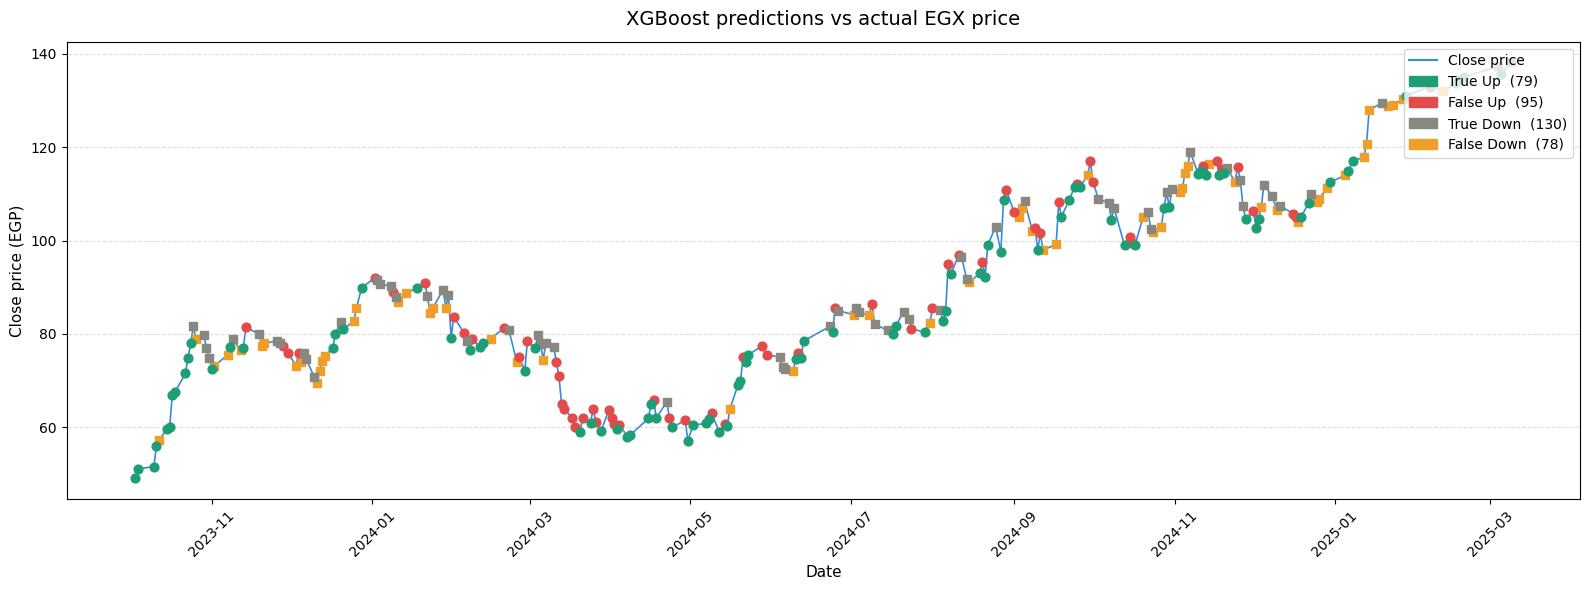

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(16, 6))

# ── Price line ──────────────────────────────────────────────────────────
ax.plot(viz_df['Date'], viz_df['Close'], 
        color='#378ADD', linewidth=1.2, zorder=1, label='Close price')

# ── Prediction markers ──────────────────────────────────────────────────
colors = {
    'True Up':    '#1D9E75',
    'False Up':   '#E24B4A',
    'True Down':  '#888780',
    'False Down': '#EF9F27',
}
markers = {
    'True Up':    'o',
    'False Up':   'o',
    'True Down':  's',
    'False Down': 's',
}

for result, group in viz_df.groupby('Result'):
    ax.scatter(group['Date'], group['Close'],
               color=colors[result],
               marker=markers[result],
               s=40, zorder=2, label=result)

# ── Formatting ──────────────────────────────────────────────────────────
ax.set_title('XGBoost predictions vs actual EGX price', fontsize=14, pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Close price (EGP)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Legend ──────────────────────────────────────────────────────────────
legend_elements = [
    mlines.Line2D([0],[0], color='#378ADD', linewidth=1.5, label='Close price'),
    mpatches.Patch(color='#1D9E75', label=f"True Up  (79)"),
    mpatches.Patch(color='#E24B4A', label=f"False Up  (95)"),
    mpatches.Patch(color='#888780', label=f"True Down  (130)"),
    mpatches.Patch(color='#EF9F27', label=f"False Down  (78)"),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('egx_predictions_ESRS.png', dpi=150, bbox_inches='tight')
plt.show()

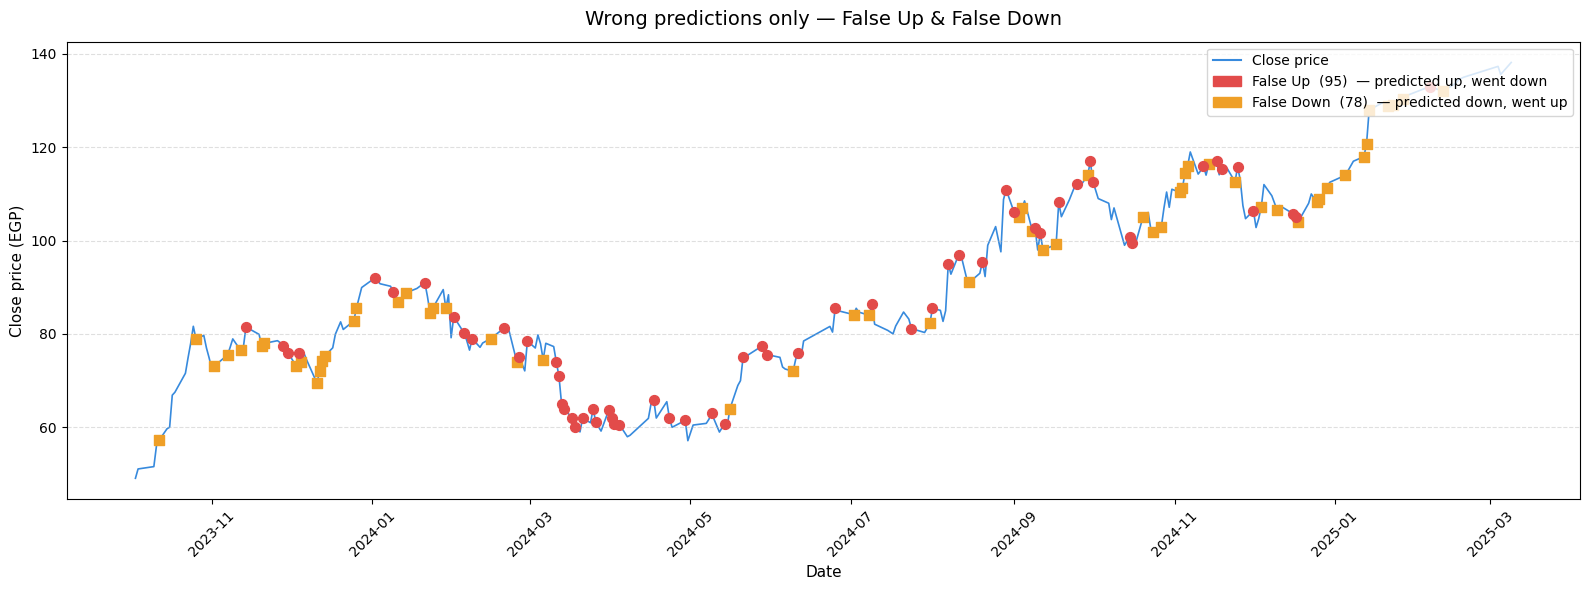

In [26]:
fig, ax = plt.subplots(figsize=(16, 6))

# ── Price line ──────────────────────────────────────────────────────────
ax.plot(viz_df['Date'], viz_df['Close'],
        color='#378ADD', linewidth=1.2, zorder=1)

# ── Wrong predictions only ──────────────────────────────────────────────
wrong = viz_df[viz_df['Result'].isin(['False Up', 'False Down'])]

colors  = {'False Up': '#E24B4A', 'False Down': '#EF9F27'}
markers = {'False Up': 'o',       'False Down': 's'}

for result, group in wrong.groupby('Result'):
    ax.scatter(group['Date'], group['Close'],
               color=colors[result],
               marker=markers[result],
               s=50, zorder=2, label=result)

# ── Formatting ──────────────────────────────────────────────────────────
ax.set_title('Wrong predictions only — False Up & False Down', fontsize=14, pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Close price (EGP)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Legend ──────────────────────────────────────────────────────────────
legend_elements = [
    mlines.Line2D([0],[0], color='#378ADD', linewidth=1.5, label='Close price'),
    mpatches.Patch(color='#E24B4A', label=f"False Up  (95)  — predicted up, went down"),
    mpatches.Patch(color='#EF9F27', label=f"False Down  (78)  — predicted down, went up"),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('egx_wrong_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

The model is just A faliure as it can't predict reversals